In [1]:
import h5py
import numpy as np

def compute_avg_fft(hdf5_file_path, ch=0):
    """
    Computes the FFT of the average waveform from an HDF5 file with waveforms stored in adc1/event_x groups.

    Parameters:
    - hdf5_file_path: str, path to the HDF5 file

    Returns:
    - freqs: 1D array of frequency bins (Hz)
    - fft_magnitude: 1D array of FFT magnitude (same length as freqs)
    """

    with h5py.File(hdf5_file_path, 'r') as f:
        adc1 = f['adc1']
        nb_samples = adc1.attrs['nb_samples']
        sample_rate = adc1.attrs['sample_rate']  # Hz
        nb_events = sum(1 for key in adc1 if key.startswith('event_'))

        # Prepare FFT accumulator
        fft_accum = np.zeros(nb_samples // 2 + 1, dtype=np.complex128)

        for i in range(1, nb_events + 1):
            event_key = f'event_{i}'
            waveform = adc1[event_key][ch,:]
            fft = np.fft.rfft(waveform)
            fft_accum += np.abs(fft)

        # Average in frequency domain
        avg_fft = fft_accum / nb_events
        avg_fft_magnitude = np.abs(avg_fft)
        freqs = np.fft.rfftfreq(nb_samples, d=1/sample_rate)

        timestamp = f.attrs['timestamp']

    return timestamp, freqs, avg_fft_magnitude


In [2]:
data_dir = '/home/qup/suerfu/data/kamioka/20250414_Kamioka_NoiseMonitor/'
_, freqs, fft_mag_ch0 = compute_avg_fft( data_dir + "Baseline_I9_D20250416_T071659_F0001.hdf5", 0)
_, freqs, fft_mag_ch1 = compute_avg_fft( data_dir + "Baseline_I9_D20250416_T071659_F0001.hdf5", 1)

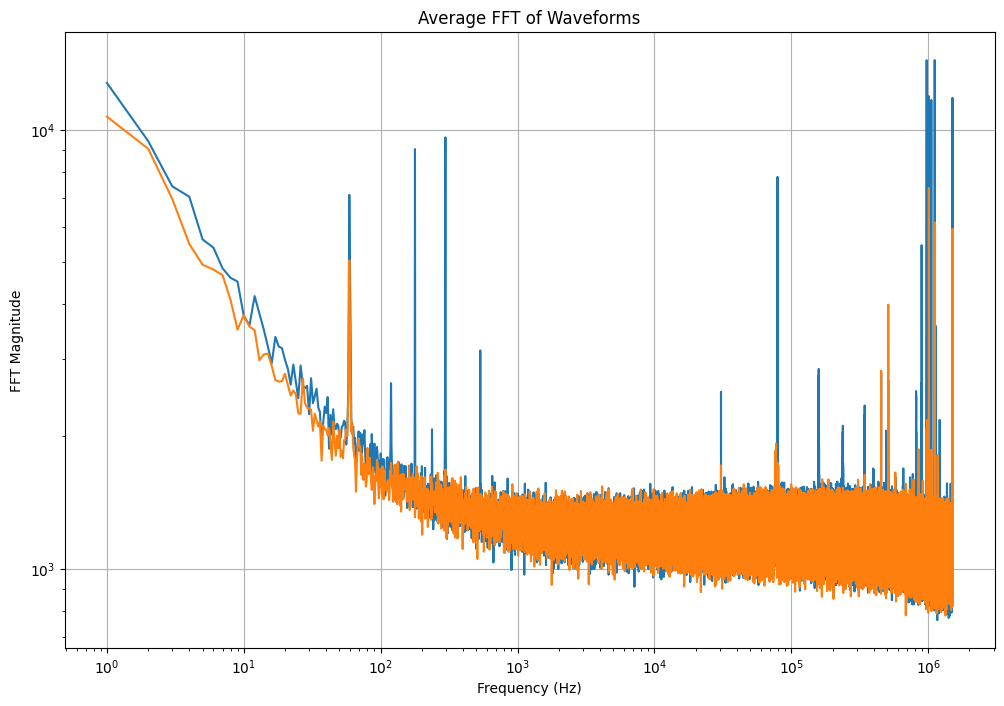

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.plot(freqs[1:], fft_mag_ch0[1:], label='Ch 0')
plt.plot(freqs[1:], fft_mag_ch1[1:], label='Ch 1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Magnitude")
plt.title("Average FFT of Waveforms")
plt.grid(True)
plt.show()


In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

def fft_time_evolution(directory, ch=0):
    # Collect relevant files
    files = sorted([
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.startswith('Baseline') and f.endswith('.hdf5')
    ])

    if not files:
        print("No matching files found.")
        return

    timestamps = []
    fft_magnitudes = []

    for file in files:
        print( 'processing', file, end='\r' )
        timestamp, freqs, magnitude = compute_avg_fft(file)
        timestamps.append(datetime.fromtimestamp(timestamp))  # convert to datetime
        fft_magnitudes.append(np.log10(magnitude + 1e-12))  # log scale (avoid log(0))

    fft_array = np.array(fft_magnitudes)

    return timestamps, fft_array

In [5]:
ts, fft_array = fft_time_evolution( data_dir )

processing /home/qup/suerfu/data/kamioka/20250414_Kamioka_NoiseMonitor/Baseline_I9_D20250416_T122809_F0001.hdf5

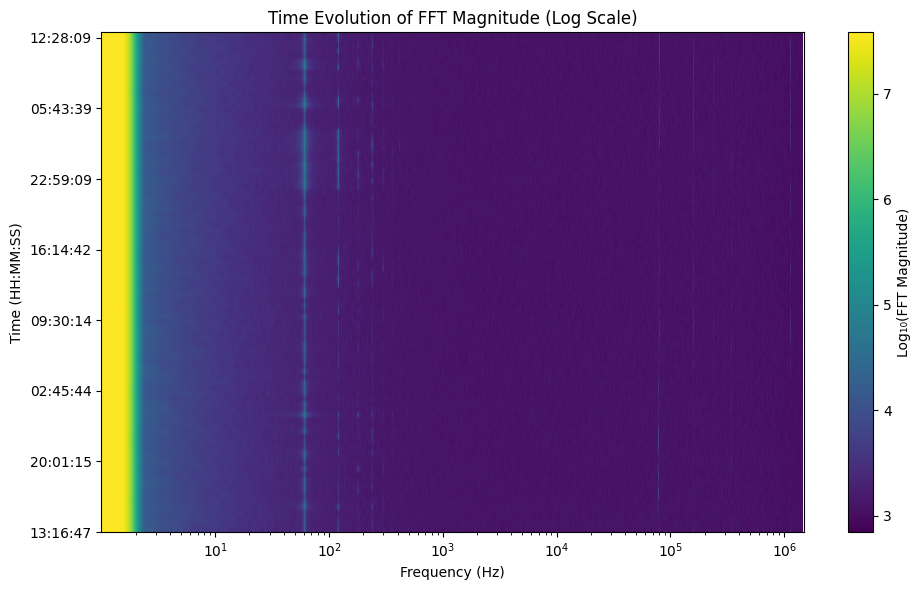

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    fft_array,
    aspect='auto',
    origin='lower',
    extent=[freqs[1], freqs[-1], 0, len(ts)],
    #norm=LogNorm(vmin=np.min(fft_array), vmax=np.max(fft_array)),
    cmap='viridis'
)

# Format Y ticks as HH:MM:SS
n_ticks = min(len(ts), 8)
tick_indices = np.linspace(0, len(ts) - 1, n_ticks, dtype=int)
ax.set_yticks(tick_indices)
ax.set_yticklabels([ts[i].strftime('%H:%M:%S') for i in tick_indices])

ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_ylabel('Time (HH:MM:SS)')
ax.set_title('Time Evolution of FFT Magnitude (Log Scale)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log₁₀(FFT Magnitude)')

plt.tight_layout()
plt.show()


In [15]:
ts, fft_array = fft_time_evolution( data_dir, 1)

processing /home/qup/suerfu/data/kamioka/20250414_Kamioka_NoiseMonitor/Baseline_I9_D20250416_T133022_F0001.hdf5

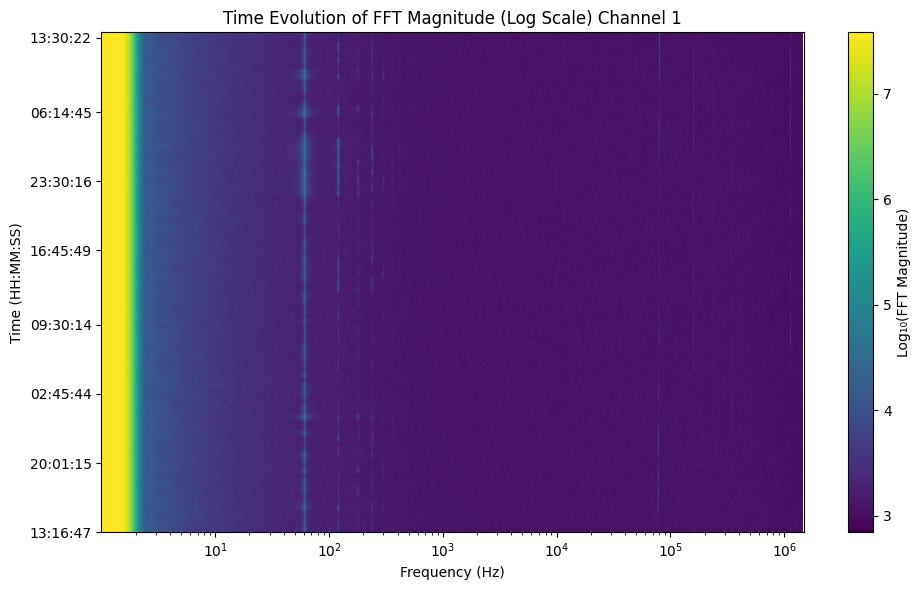

In [21]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    fft_array,
    aspect='auto',
    origin='lower',
    extent=[freqs[1], freqs[-1], 0, len(ts)],
    #norm=LogNorm(vmin=np.min(fft_array), vmax=np.max(fft_array)),
    cmap='viridis'
)

# Format Y ticks as HH:MM:SS
n_ticks = min(len(ts), 8)
tick_indices = np.linspace(0, len(ts) - 1, n_ticks, dtype=int)
ax.set_yticks(tick_indices)
ax.set_yticklabels([ts[i].strftime('%H:%M:%S') for i in tick_indices])

ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_ylabel('Time (HH:MM:SS)')
ax.set_title('Time Evolution of FFT Magnitude (Log Scale) Channel 1')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log₁₀(FFT Magnitude)')

plt.tight_layout()
plt.show()

In [3]:
import h5py
import numpy as np

def compute_avg_fft(hdf5_file_path, ch=0):
    """
    Computes the FFT of the average waveform from an HDF5 file with waveforms stored in adc1/event_x groups.

    Parameters:
    - hdf5_file_path: str, path to the HDF5 file

    Returns:
    - freqs: 1D array of frequency bins (Hz)
    - fft_magnitude: 1D array of FFT magnitude (same length as freqs)
    """

    with h5py.File(hdf5_file_path, 'r') as f:
        adc1 = f['adc_0']
        nb_samples = adc1.attrs['nb_samples']
        sample_rate = adc1.attrs['board_sampling_rate']  # Hz
        nb_events = sum(1 for key in adc1 if key.startswith('event_'))

        # Prepare FFT accumulator
        fft_accum = np.zeros(nb_samples // 2 + 1, dtype=np.complex128)

        for i in range(0, nb_events):
            event_key = f'event_{i}'
            waveform = adc1[event_key][ch,:]
            fft = np.fft.rfft(waveform)
            fft_accum += np.abs(fft)

        # Average in frequency domain
        avg_fft = fft_accum / nb_events
        avg_fft_magnitude = np.abs(avg_fft)
        freqs = np.fft.rfftfreq(nb_samples, d=1/sample_rate)

        timestamp = f.attrs['timestamp']

    return timestamp, freqs, avg_fft_magnitude


In [7]:
data_dir = '/home/qup/suerfu/data/kamioka/gamma/20250325_NaI_Kamioka/'
_, freqs, fft_mag_ch0 = compute_avg_fft( data_dir + "Baseline_Run53_20250330_175631.hdf5", 0)
_, freqs, fft_mag_ch1 = compute_avg_fft( data_dir + "Baseline_Run53_20250330_175631.hdf5", 1)

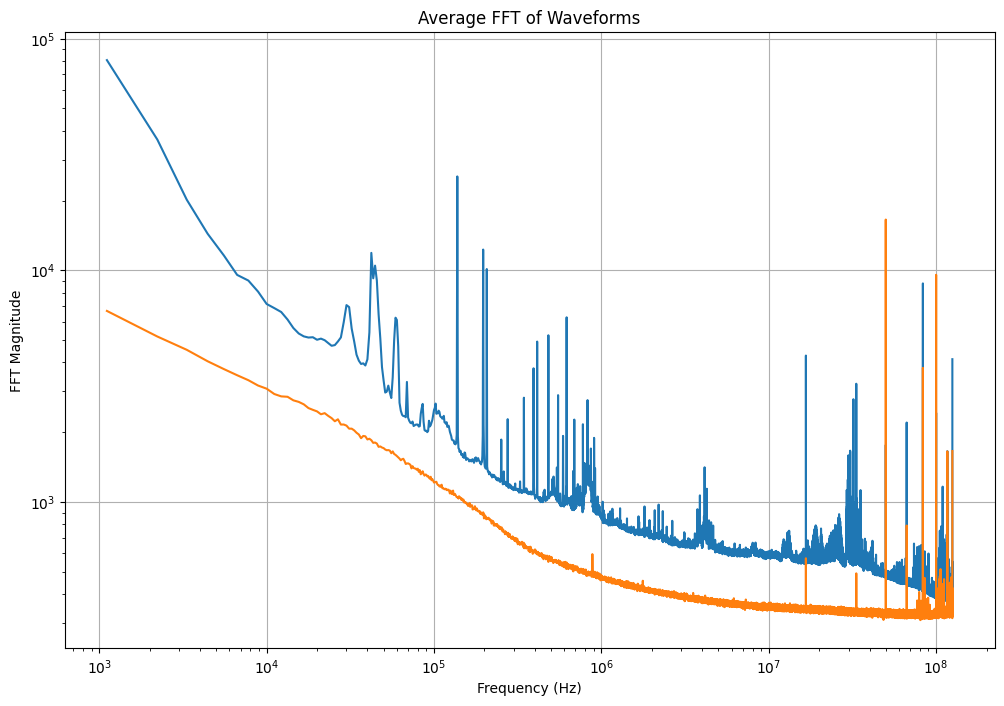

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.plot(freqs[1:], fft_mag_ch0[1:], label='Ch 0')
plt.plot(freqs[1:], fft_mag_ch1[1:], label='Ch 1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Magnitude")
plt.title("Average FFT of Waveforms")
plt.grid(True)
plt.show()

In [9]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

def fft_time_evolution(directory, ch=0):
    # Collect relevant files
    files = sorted([
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.startswith('Baseline') and f.endswith('.hdf5')
    ])

    if not files:
        print("No matching files found.")
        return

    timestamps = []
    fft_magnitudes = []

    for file in files:
        print( 'processing', file, end='\r' )
        timestamp, freqs, magnitude = compute_avg_fft(file)
        timestamps.append(datetime.fromtimestamp(timestamp))  # convert to datetime
        fft_magnitudes.append(np.log10(magnitude + 1e-12))  # log scale (avoid log(0))

    fft_array = np.array(fft_magnitudes)

    return timestamps, fft_array

In [10]:
ts, fft_array = fft_time_evolution( data_dir )

processing /home/qup/suerfu/data/kamioka/gamma/20250325_NaI_Kamioka/Baseline_Run9_20250328_212437.hdf55

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    fft_array,
    aspect='auto',
    origin='lower',
    extent=[freqs[1], freqs[-1], 0, len(ts)],
    #norm=LogNorm(vmin=np.min(fft_array), vmax=np.max(fft_array)),
    cmap='viridis'
)

# Format Y ticks as HH:MM:SS
n_ticks = min(len(ts), 8)
tick_indices = np.linspace(0, len(ts) - 1, n_ticks, dtype=int)
ax.set_yticks(tick_indices)
ax.set_yticklabels([ts[i].strftime('%H:%M:%S') for i in tick_indices])

ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_ylabel('Time (HH:MM:SS)')
ax.set_title('Time Evolution of FFT Magnitude (Log Scale)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log₁₀(FFT Magnitude)')

plt.tight_layout()
plt.show()